In [1]:
import os
import pandas as pd
from ORBIT import ProjectManager, load_config
import csv
import matplotlib.pyplot as plt

In [2]:
#df would be the installation durations dataframe
def create_list_tuples_vessel_increases(df, max_percentage_raise, vessel_rates):
    tuple_list = list()
    baseline_dayrate = vessel_rates/ 24
    WTIV_time = df.loc[df['agent'] == "WTIV"] ['duration'].sum()
    port_time = df.loc[df['agent'] == "Port"] ['duration'].sum()
    baseline_port_fee = df.loc[df['agent'] == "Port"] ['day_rate'].iloc[0] / 24

    
    for i in range (0,max_percentage_raise+10, 10):
        increase = (1+i/100)
        install_cost = port_time * baseline_port_fee + WTIV_time * baseline_dayrate * increase
        tuple_list.append((i, install_cost))

    return tuple_list

def percentage_equalizer_vessel(df_1, df_2, vessel_rates):
    baseline_dayrate_1 = vessel_rates/ 24
    WTIV_time_1 = df_1.loc[df_1['agent'] == "WTIV"] ['duration'].sum()
    port_time_1 = df_1.loc[df_1['agent'] == "Port"] ['duration'].sum()
    baseline_port_fee_1 = df_1.loc[df_1['agent'] == "Port"] ['day_rate'].iloc[0] / 24

    baseline_dayrate_2 = vessel_rates/ 24
    WTIV_time_2 = df_2.loc[df_2['agent'] == "WTIV"] ['duration'].sum()
    port_time_2 = df_2.loc[df_2['agent'] == "Port"] ['duration'].sum()
    baseline_port_fee_2 = df_2.loc[df_2['agent'] == "Port"] ['day_rate'].iloc[0] / 24

    y = (baseline_port_fee_1 * port_time_1 - baseline_port_fee_2 * port_time_2) - baseline_dayrate_2 * WTIV_time_2 + baseline_dayrate_1 * WTIV_time_1
    x = 100 * y / (baseline_dayrate_2 * WTIV_time_2)
    return x

def create_list_tuples_intallation_time_increases(df, max_percentage_raise, vessel_rates):
    
    tuple_list = list()
    baseline_dayrate = vessel_rates/ 24
    WTIV_time = df.loc[df['agent'] == "WTIV"] ['duration'].sum()
    port_time = df.loc[df['agent'] == "Port"] ['duration'].sum()
    baseline_port_fee = df.loc[df['agent'] == "Port"] ['day_rate'].iloc[0] / 24
    #count number of mobilizations to substract accordingly
    mobilize_count = df['action'].value_counts()["Mobilize"]
    
    
    for i in range (0,max_percentage_raise+10, 10):
        increase = (1+i/100)
        install_cost = (port_time + (WTIV_time - mobilize_count*168) * (increase-1)) * baseline_port_fee + (mobilize_count*168 + (WTIV_time - mobilize_count*168) * increase)* baseline_dayrate
        tuple_list.append((i, install_cost))

    return tuple_list

def percentage_equalizer_times(df_1, df_2, vessel_rates):
    baseline_dayrate_1 = vessel_rates/ 24
    WTIV_time_1 = df_1.loc[df_1['agent'] == "WTIV"] ['duration'].sum()
    port_time_1 = df_1.loc[df_1['agent'] == "Port"] ['duration'].sum()
    baseline_port_fee_1 = df_1.loc[df_1['agent'] == "Port"] ['day_rate'].iloc[0] / 24

    baseline_dayrate_2 = vessel_rates/ 24
    WTIV_time_2 = df_2.loc[df_2['agent'] == "WTIV"] ['duration'].sum()
    port_time_2 = df_2.loc[df_2['agent'] == "Port"] ['duration'].sum()
    baseline_port_fee_2 = df_2.loc[df_2['agent'] == "Port"] ['day_rate'].iloc[0] / 24

    #count number of mobilizations to substract accordingly
    mobilize_count = df_1['action'].value_counts()["Mobilize"]

    a = baseline_port_fee_1 * port_time_1 + baseline_dayrate_1 * WTIV_time_1

    y = a - baseline_port_fee_2 * port_time_2 - baseline_dayrate_2 * (WTIV_time_2-168*mobilize_count)
    
    x = (y - mobilize_count*168*baseline_dayrate_2)*100/((WTIV_time_2-mobilize_count*168)*(baseline_dayrate_2 + baseline_port_fee_2))
    
    return x


# Merge Monopile and Turbine Install.

In [3]:
def plot_comparison_merged(MW_15_list_vessel, MW_20_list_vessel, equalizer_vessel, MW_15_list_times, MW_20_list_times, equalizer_times, vessel_rates):

    x_val_15_vessel = [x[0] for x in MW_15_list_vessel]
    y_val_15_vessel = [x[1] for x in MW_15_list_vessel]

    x_val_20_vessel = [x[0] for x in MW_20_list_vessel]
    y_val_20_vessel = [x[1] for x in MW_20_list_vessel]

    x_val_15_times = [x[0] for x in MW_15_list_times]
    y_val_15_times = [x[1] for x in MW_15_list_times]

    x_val_20_times = [x[0] for x in MW_20_list_times]
    y_val_20_times = [x[1] for x in MW_20_list_times]

    
    plt.scatter(x_val_15_vessel, y_val_15_vessel, color = "royalblue", edgecolor = "black", marker = "v", zorder = 50)
    #plt.scatter(x_val_15_times, y_val_15_times, color = "royalblue", linewidth=2, marker = "v", zorder = 50)
    plt.plot(x_val_20_times, y_val_20_times, color = "red", linewidth=2, marker = None, zorder = 50, linestyle = ":")
    plt.plot(x_val_20_vessel, y_val_20_vessel, color = "red", linewidth=2, marker = None, zorder = 50, linestyle = "-.")
    
    
    plt.legend(["40 x 15-MW WTGs", "30 x 20-MW WTGs, Increase in Install. Times per WTG", "30 x 20-MW WTGs, Increase in Install. Vessel Rates"], fontsize = 10, loc = "upper left")
    plt.plot([0, equalizer_vessel], [y_val_15_vessel[0], y_val_15_vessel[0]], "--", color = "grey")
    plt.plot([0, equalizer_times], [y_val_15_times[0], y_val_15_times[0]], "--", color = "grey")
    
    plt.plot([equalizer_vessel, equalizer_vessel], [0, y_val_15_vessel[0]], "--", color = "grey")
    plt.plot([equalizer_times, equalizer_times], [0, y_val_15_times[0]], "--", color = "grey")
    
    plt.scatter(equalizer_vessel, y_val_15_vessel[0], color = "yellow", linewidth=1, marker = "*", edgecolor = "black", s = 100, zorder = 100)
    plt.scatter(equalizer_times, y_val_15_times[0], color = "yellow", linewidth=1, marker = "*", edgecolor = "black", s = 100, zorder = 100)
    
    plt.text(equalizer_vessel + 1, y_val_15_vessel[0]*0.97, str(int(equalizer_vessel+0.5))+"%", fontweight='bold')
    plt.text(equalizer_times - 2, y_val_15_times[0]*1.015, str(int(equalizer_times+0.5))+"%", fontweight='bold')
    
    plt.xlim((-0.5, 37))
    plt.ylim((min(y_val_20_vessel[0], y_val_20_times[0])*0.8, max(y_val_20_vessel[-1], y_val_20_times[-1])))
    plt.ylabel('Monopile and Turbine Installation CapEx ($)')
    plt.xlabel('Percentage Increase (%)')
    #plt.title('Fixed-bottom')
    plt.grid()
    plt.savefig("plots/merged_vessel_install_" + str(vessel_rates/1000) + "k.svg")
    plt.savefig("plots/merged_vessel_install_" + str(vessel_rates/1000) + "k.png")
    plt.show()
    

df_15_mon = pd.read_csv("data/monopile_output_15_MW.csv")
df_20_mon = pd.read_csv("data/monopile_output_20_MW.csv")
df_15_tur = pd.read_csv("data/turbine_output_15_MW.csv")
df_20_tur = pd.read_csv("data/turbine_output_20_MW.csv")

df_15 = pd.concat([df_15_mon, df_15_tur], axis=0)
df_20 = pd.concat([df_20_mon, df_20_tur], axis=0)

vessel_rates = 250000

MW_15_list_vessel = create_list_tuples_vessel_increases(df_15, 0, vessel_rates)
MW_20_list_vessel = create_list_tuples_vessel_increases(df_20, 60, vessel_rates)

equalizer_vessel = percentage_equalizer_vessel(df_15, df_20, vessel_rates)

MW_15_list_times = create_list_tuples_intallation_time_increases(df_15, 0, vessel_rates)
MW_20_list_times = create_list_tuples_intallation_time_increases(df_20, 60, vessel_rates)

equalizer_times = percentage_equalizer_times(df_15, df_20, vessel_rates)

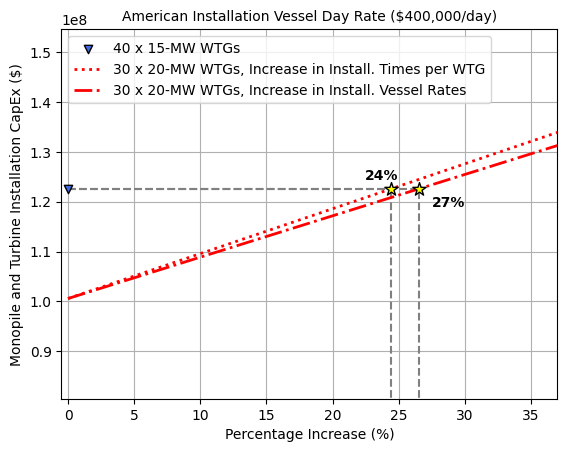

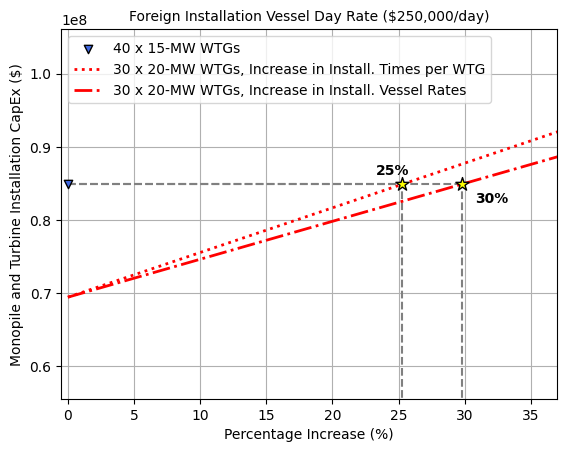

In [4]:
vessel_rates = [400000, 250000]
df_15_mon = pd.read_csv("data/monopile_output_15_MW.csv")
df_20_mon = pd.read_csv("data/monopile_output_20_MW.csv")
df_15_tur = pd.read_csv("data/turbine_output_15_MW.csv")
df_20_tur = pd.read_csv("data/turbine_output_20_MW.csv")
df_15 = pd.concat([df_15_mon, df_15_tur], axis=0)
df_20 = pd.concat([df_20_mon, df_20_tur], axis=0)
for i in vessel_rates:
    
    MW_15_list_vessel = create_list_tuples_vessel_increases(df_15, 0, i)
    MW_20_list_vessel = create_list_tuples_vessel_increases(df_20, 60, i)

    equalizer_vessel = percentage_equalizer_vessel(df_15, df_20, i)

    if i == 250000:
        plt.title("Foreign Installation Vessel Day Rate ($250,000/day)", fontsize = 10)
    else:
        plt.title("American Installation Vessel Day Rate ($400,000/day)", fontsize = 10)

    MW_15_list_times = create_list_tuples_intallation_time_increases(df_15, 0, i)
    MW_20_list_times = create_list_tuples_intallation_time_increases(df_20, 60, i)

    equalizer_times = percentage_equalizer_times(df_15, df_20, i)


    plot_comparison_merged(MW_15_list_vessel, MW_20_list_vessel, equalizer_vessel, MW_15_list_times, MW_20_list_times, equalizer_times, i)

In [5]:
df_15_mon = pd.read_csv("data/monopile_output_15_MW.csv")
df_20_mon = pd.read_csv("data/monopile_output_20_MW.csv")
df_15_tur = pd.read_csv("data/turbine_output_15_MW.csv")
df_20_tur = pd.read_csv("data/turbine_output_20_MW.csv")
df_15 = pd.concat([df_15_mon, df_15_tur], axis=0)
df_20 = pd.concat([df_20_mon, df_20_tur], axis=0)
MW_15_list_vessel = create_list_tuples_vessel_increases(df_15, 0, 400000)
MW_20_list_vessel = create_list_tuples_vessel_increases(df_20, 60, 400000)
value_1 = MW_15_list_vessel[0][1]
value_2 = MW_20_list_vessel[0][1]

In [6]:
print(value_2)
print(value_1)
print((value_2-value_1)/value_1)

100561975.18763313
122575051.35308798
-0.17958855348177086
